In [1]:
from jqdata import *
from jqfactor import (get_factor_values,calc_factors,Factor)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
from scipy.optimize import minimize

from tqdm import tqdm_notebook
from dateutil.parser import parse
from dateutil.relativedelta import relativedelta
import seaborn as sns
from matplotlib import rcParams
import warnings

warnings.filterwarnings("ignore")

rcParams['font.family']=['stHeiti']
rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn')


# 定义计算因子类

In [2]:
class EPTTM(Factor):
    name = 'EPTTM'
    max_window = 1
    dependencies = ['pe_ratio']
    
    def calc(self,data):
        return (1/data['pe_ratio']).iloc[0]
    
class SPTTM(Factor):
    name = 'SPTTM'
    max_window = 1
    dependcies = ['ps_ttm']
    
    def calc(self,data):
        return (1/data['ps_ttm']).iloc[0]

class SUE0(Factor):
    name = 'SUE0'
    max_window = 1
    dependencies = [f'net_profit_{i}' if i!=0 else 'net_profit' for i in range(9)]
    
    def calc(self,data):
        a = [v.T for v in data.values()]
        b = pd.concat(a,axis=1)
        b.fillna(0,inplace= True)
        
        c_ser = np.mean(b.iloc[:,1:5].values-b.iloc[:,5:].values,axis = 1)
        epsilon = np.std(b.iloc[:,1:5].values-b.iloc[:,5:].values,axis = 1)
        1
        pre_ser = b.iloc[:,4] + c_ser + epsilon
        return (b.iloc[:,0]-pre_ser)/epsilon

class SUR0(Factor):
    name = 'SUR0'
    max_window = 1
    dependencies = [f'operating_revenue_{i}' if i!=0 else 'operating_revenue' for i in range(9)]

    def calc(self,data):
        a = [v.T for v in data.values()]
        b = pd.concat(a,axis=1)
        b.fillna(0,inplace= True)

        c_ser = np.mean(b.iloc[:,1:5].values-b.iloc[:,5:].values,axis = 1)
        epsilon = np.std(b.iloc[:,1:5].values-b.iloc[:,5:].values,axis = 1)

        pre_ser = b.iloc[:,4] + c_ser + epsilon
        return (b.iloc[:,0]-pre_ser)/epsilon
    
    
class DELTAROE(Factor):
    name = 'DELTAROE'
    max_window = 1
    dependencies = ['roe','roe_4']
    
    def calc(self,data):
        return (data['roe']-data['roe_4']).iloc[0]
    
class DELTAROA(Factor):
    
    name = 'DELTAROA'
    max_window = 1
    dependencies = ['roa','roa_4']
    
    def calc(self,data):        
        
        return (data['roa'] - data['roa_4']).iloc[0]
    
class ILLIQ(Factor):
    name = 'ILLIQ'
    max_window = 22
    dependencies = ['close','money']
    
    def calc(self,data):
        a = np.abs(data['close'].pct_change().shift(1).iloc[2:])
        b = data['money'].shift(1).iloc[2:]
        c = (a/b)
        return c.mean()
    
class ATR1M(Factor):
    name = 'ATR1M'
    max_window = 22
    dependencies = ['close','high','low']
    
    def calc(self,data):
        a = data['close'].shift(1).iloc[1:]
        b = data['high'].shift(1).iloc[1:]
        c = data['low'].shift(1).iloc[1:]
        tmp = np.maximum(b-c,np.abs(a.shift(1)-b))
        d = np.maximum(tmp,abs(a.shift(1)-c))
        return d.iloc[-20:].mean()
    
class ATR3M(Factor):
    name = 'ATR3M'
    max_window = 62
    dependencies = ['close','high','low']
    
    def calc(self,data):
        a = data['close'].shift(1).iloc[1:]
        b = data['high'].shift(1).iloc[1:]
        c = data['low'].shift(1).iloc[1:]
        tmp = np.maximum(b-c,np.abs(a.shift(1)-b))
        d = np.maximum(tmp,abs(a.shift(1)-c))
        return d.iloc[-60:].mean()


# 筛选股票列表（1.去掉st 2.去掉发行时间不足1年新股 3.去掉当日以及15内停牌）

In [3]:
class FilterStocks():
    def __init__(self,symbol:str,watch_date:str,N:int= 3,n:int=15):
        self.symbol = symbol
        self.watch_date = parse(watch_date).date()
        self.N = N
        self.n = n
    
    @property
    def get_stocks(self):
        if self.symbol == 'A':
            stockList = get_index_stocks('000002.XSHG',date = self.watch_date)+\
            get_index_stocks('399107.XSHE',date = self.watch_date)
        else:
            stockList = get_index_stocks(self.symbol,date=self.watch_date)
            
            
            
        st_data = get_extras('is_st',stockList,end_date = self.watch_date,count=1).iloc[0]
        stockList = st_data[st_data==False].index.tolist()
        
        stockList = self.del_new(stockList,self.watch_date,self.N)
        
        stockList = self.del_pause(stockList,self.watch_date,self.n)
        
        return stockList
    
    @staticmethod
    def del_new(stocks: list, time: datetime.date, period: int):
        # 一次性获取所有股票的基础信息（只需要上市日期）
        all_info = get_all_securities(types=['stock'], date=time)
        # 只保留传入股票列表中的那些
        info_subset = all_info[all_info.index.isin(stocks)]

        threshold = time - relativedelta(months=period)
        # 筛选上市日期 <= 阈值的股票
        return info_subset[info_subset.start_date <= threshold].index.tolist()

    @staticmethod
    def del_pause(stocks:list,time:datetime.date,n:int):
        end_date = time.strftime('%Y-%m-%d')
        
        tmp = get_price(stocks,end_date=end_date, count=n,fields='paused',panel = False)
        a = tmp.groupby('code').apply(lambda x : (len(x)==n) & (x['paused'].sum()==0))
        b = a[a==True].index.tolist()
        return b
        
        

# 计算因子 --此处因子库参考--天风证券-基于自适应风险控制的指数增强策略

In [9]:
# 计算因子
def get_factor(func,symbol:str, start_date:str,end_date:str,freq:str='ME'):
    period = getTradeDate(start_date,end_date,freq)
    factor_dic = {}
    for p in period:
        p = p.strftime('%Y-%m-%d')
        stocks = FilterStocks(symbol,p,N=12,n=15).get_stocks
        factor_dic[p] = func(stocks,p)
    factor_df = pd.concat(factor_dic)
    factor_df.index.names = ['date','code']
    
    return factor_df
        
    
    
    
def getTradeDate(start:str,end:str,freq:str)->list:
    tmp = pd.to_datetime(get_trade_days(start,end))
    tmp_df = tmp.to_frame()
    
    if freq[-1] == 'E':
        tmp_df = tmp_df.resample(freq[0]).last()
    else:
        tmp_df = tmp_df.resample(freq[0]).first()


    tmp_ser = tmp_df[0].dt.date
    return tmp_ser.dropna().values.tolist()


def dict2frame(dic:dict)->pd.DataFrame:
    tmp = [v.T for v in dic.values()]
    tmp_df = pd.concat(tmp,axis=1)
    names = [n.upper() for n in dic.keys()]
    tmp_df.columns = names
    return tmp_df

def calc_factor(stocks:list,watch_date:str)-> pd.DataFrame:
    fields = ['natural_log_of_market_cap', 'book_to_price_ratio',
              'ROC20', 'ROC60',
              'net_profit_growth_rate', 'operating_revenue_growth_rate',
              'total_profit_growth_rate', 'roe_ttm',
              'roa_ttm', 'VOL20',
              'VOL60']
    part1 = get_factor_values(stocks,factors = fields,start_date = watch_date,end_date=watch_date)
    part1 = dict2frame(part1)
    
    # 自定义因子
    fields = [EPTTM(), SUE0(),SUR0(), DELTAROE(), DELTAROA(),ILLIQ(), ATR1M(), ATR3M()]
    part2 = calc_factors(stocks,factors = fields,start_date = watch_date,end_date=watch_date)
    part2 = dict2frame(part2)
    
    # 新增：单独拿 SPTTM，3行搞定
    ps = get_fundamentals(query(valuation.code, valuation.ps_ratio).filter(valuation.code.in_(stocks)), date=watch_date)
    ps = ps.set_index('code')
    part2['SPTTM'] = 1 / ps['ps_ratio']   # 直接插到 part_b 里
    
    # 市值以及行业信息
    part3= IndustryMktcap(stocks,watch_date)
    factor_df = pd.concat([part1,part2,part3],axis=1)
    return factor_df
    

def IndustryMktcap(stocks:list,watch_date:str)->pd.DataFrame:
    ind = get_industry(stocks,watch_date)
    ind_dic = {k:v.get('sw_l1',{'industry_code':np.nan})['industry_code'] for k,v in ind.items()}
    ind_ser = pd.Series(ind_dic)
    ind_ser.name = 'industry_code'.upper()
    
    mkt_cap = get_valuation(stocks,end_date = watch_date,count=1,fields = 'market_cap').set_index('code')['market_cap']
    ind_mkt = pd.concat([ind_ser,mkt_cap],axis=1)
    return ind_mkt

In [3]:
# 设置时间范围
START_DATE = '2010-01-01'
END_DATE = '2020-09-30'


# 因子获取
factors = get_factor(calc_factor,'000300.XSHG',START_DATE,END_DATE)
# 因子储存
factors.to_csv('index_enhancement.csv')

In [4]:
# 因子读取
factors = pd.read_csv('index_enhancement.csv',index_col=[0,1],parse_dates=[0],dtype={'INDUSTRY_CODE':str})

# 查看数据结构
factors.head()


VOL60     ...      market_cap
date       code                      ...                
2010-01-29 000001.XSHE  1.183183     ...        673.8791
           000002.XSHE  1.661527     ...       1026.9526
           000009.XSHE  2.716385     ...        113.7653
           000012.XSHE  2.807852     ...        223.1420
           000021.XSHE  1.484897     ...        114.6892

[5 rows x 22 columns]

# 处理因子数据：1.处理缺失值；2.处理极值（绝对中位数法MAD）；3.标准化；4.行业市值中心化

In [5]:
# 处理空值：使用行业中位数
def factor_null_process(data:pd.DataFrame)->pd.DataFrame:
    data = data.copy()
    factor_list = [c for c in data.columns if c not in ['INDUSTRY_CODE', 'market_cap', 'date']]
    
    # 先删除行业缺失的
    data = data[data['INDUSTRY_CODE'].notna()]
    
    # 用 transform 一次性填充：C 语言级别循环，比 apply+lambda 快 20 倍
    # 对数值列，按行业取中位数，然后 fillna
    for col in factor_list:
        data[col] = data.groupby('INDUSTRY_CODE')[col].transform(
            lambda x: x.fillna(x.median())
        )
    
    # 剩余缺失（整个行业都缺失的情况）填 0
    data[factor_list] = data[factor_list].fillna(0)
    return data


# 使用绝对中位数法MAD去极值
def factor_extreme_process(data:pd.DataFrame)->pd.DataFrame:
    data = data.copy()
    factor_list = [i for i in data.columns.tolist() if i not in ['INDUSTRY_CODE','market_cap']]  
    
    median = data[factor_list].median(axis = 0)
    mad = np.abs(data[factor_list].sub(median,axis =1)).median(axis = 0)
    data[factor_list] = data[factor_list].clip(lower = median-3*1.4826*mad,upper = median+3*1.4826*mad,axis =1)
    return data
    
# 标准化
def data_scale_Z_Score(data:pd.DataFrame)->pd.DataFrame:
    data = data.copy()
    factor_list = [i for i in data.columns.tolist() if i not in ['INDUSTRY_CODE','market_cap']]  
    data.loc[:,factor_list] = (data.loc[:,factor_list]-data.loc[:,factor_list].mean())/data.loc[:,factor_list].std()
    return data

# 行业、市值中性化
def neutralization(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    factor_list = [i for i in data.columns.tolist() if i not in ['INDUSTRY_CODE','market_cap']]  
    
#     def calc_resid(x: pd.DataFrame, y: pd.Series) -> float:

#         result = sm.OLS(y, x).fit()

#         return result.resid
    
    x_df = pd.get_dummies(data['INDUSTRY_CODE'])
    x_df['market_cap'] = np.log(data['market_cap'] * 100000000)
    
    X = x_df.values.astype(float)  # N × M
    Y = data[factor_list].values.astype(float) 
    
    B, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=None)
    
    # 计算残差
    resid = Y - X @ B  # N × K
    
    # 写回 DataFrame
    data[factor_list] = resid
    
#   data.loc[:,factor_list] = pd.concat([calc_resid(x_df.fillna(0),data[i]) for i in factor_list],axis=1)
    return data

In [8]:
# 去极值
factors1 = factors.groupby(level='date').apply(factor_extreme_process)
# 缺失值处理
factors2 = factors1.groupby(level='date').apply(factor_null_process)
# 中性化
factors3 = factors2.groupby(level='date').apply(neutralization)
# 标准化
factors4 = factors3.groupby(level='date').apply(data_scale_Z_Score)

print(factors.info())
print('去缺失值:')
print(factors2.info())

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 34603 entries, (2010-01-29 00:00:00, 000001.XSHE) to (2020-09-30 00:00:00, 603993.XSHG)
Data columns (total 22 columns):
VOL60                            34603 non-null float64
NATURAL_LOG_OF_MARKET_CAP        34603 non-null float64
ROA_TTM                          34601 non-null float64
ROC20                            34603 non-null float64
OPERATING_REVENUE_GROWTH_RATE    33481 non-null float64
BOOK_TO_PRICE_RATIO              34603 non-null float64
VOL20                            34603 non-null float64
ROC60                            34603 non-null float64
ROE_TTM                          34601 non-null float64
TOTAL_PROFIT_GROWTH_RATE         33515 non-null float64
NET_PROFIT_GROWTH_RATE           33515 non-null float64
EPTTM                            34603 non-null float64
SUE0                             34603 non-null float64
SUR0                             34603 non-null float64
DELTAROE                         34307 non-nu

In [9]:
factors4.to_csv('factors4.csv')

In [10]:
def lowdin_orthogonal(data:pd.DataFrame)->pd.DataFrame:
    data = data.copy()
    factor_list = [i for i in data.columns.tolist() if i not in ['INDUSTRY_CODE','market_cap']] 
    F = np.mat(data[factor_list])
    M = F.T @ F
    # 对M进行特征值分解
    a,U = np.linalg.eig(M)
    D = np.linalg.inv(np.diag(a))
    S = U @ np.sqrt(D) @ U.T
    
    data[factor_list] = data[factor_list]@S
    return data
    
    
    

In [11]:
# 数据读取
factors4 = pd.read_csv('factors4.csv',index_col=[0,1],parse_dates=[0],dtype={'INDUSTRY_CODE':str})

#对称正交化
factors5 = factors4.groupby(level='date').apply(lowdin_orthogonal)  
factors5.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 34603 entries, (2010-01-29 00:00:00, 000001.XSHE) to (2020-09-30 00:00:00, 603993.XSHG)
Data columns (total 22 columns):
VOL60                            34603 non-null float64
NATURAL_LOG_OF_MARKET_CAP        34603 non-null float64
ROA_TTM                          34603 non-null float64
ROC20                            34603 non-null float64
OPERATING_REVENUE_GROWTH_RATE    34603 non-null float64
BOOK_TO_PRICE_RATIO              34603 non-null float64
VOL20                            34603 non-null float64
ROC60                            34603 non-null float64
ROE_TTM                          34603 non-null float64
TOTAL_PROFIT_GROWTH_RATE         34603 non-null float64
NET_PROFIT_GROWTH_RATE           34603 non-null float64
EPTTM                            34603 non-null float64
SUE0                             34603 non-null float64
SUR0                             34603 non-null float64
DELTAROE                         34603 non-nu

In [17]:
#构建计算横截面因子载荷相关系数均值函数
def get_relations(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    factor_list = [i for i in data.columns.tolist() if i not in ['INDUSTRY_CODE','market_cap']] 
    
    relation = 0
    for time,d in data.groupby(level = 'date'):
        relation += d[factor_list].corr()
        
    relation = relation/len(data.index.levels[0])
    return relation
    

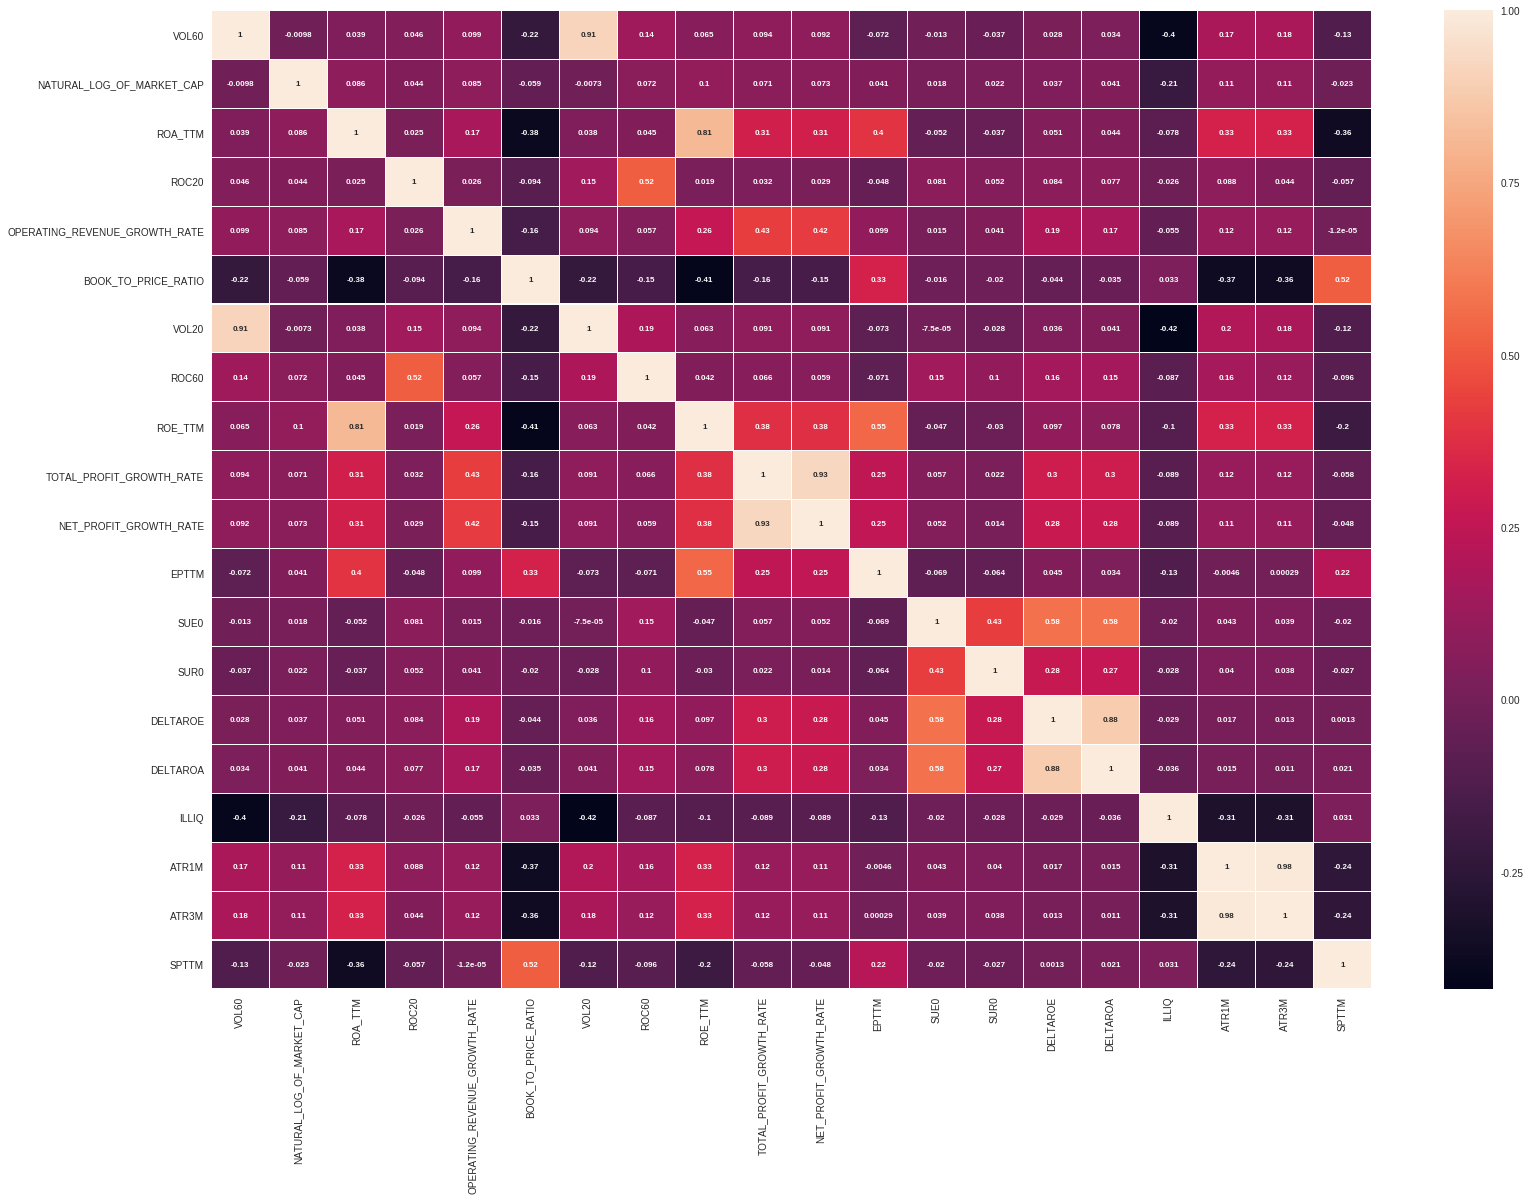

In [18]:
# 绘制因子正交前的相关性的热力图
fig = plt.figure(figsize=(26, 18))
# 计算对称正交之前的相关系数矩阵
relations = get_relations(factors4)  
sns.heatmap(relations, annot=True, linewidths=0.05,
            linecolor='white', annot_kws={'size': 8, 'weight': 'bold'})

#  可见对称正交化之后，因子之间的相关性大大降低

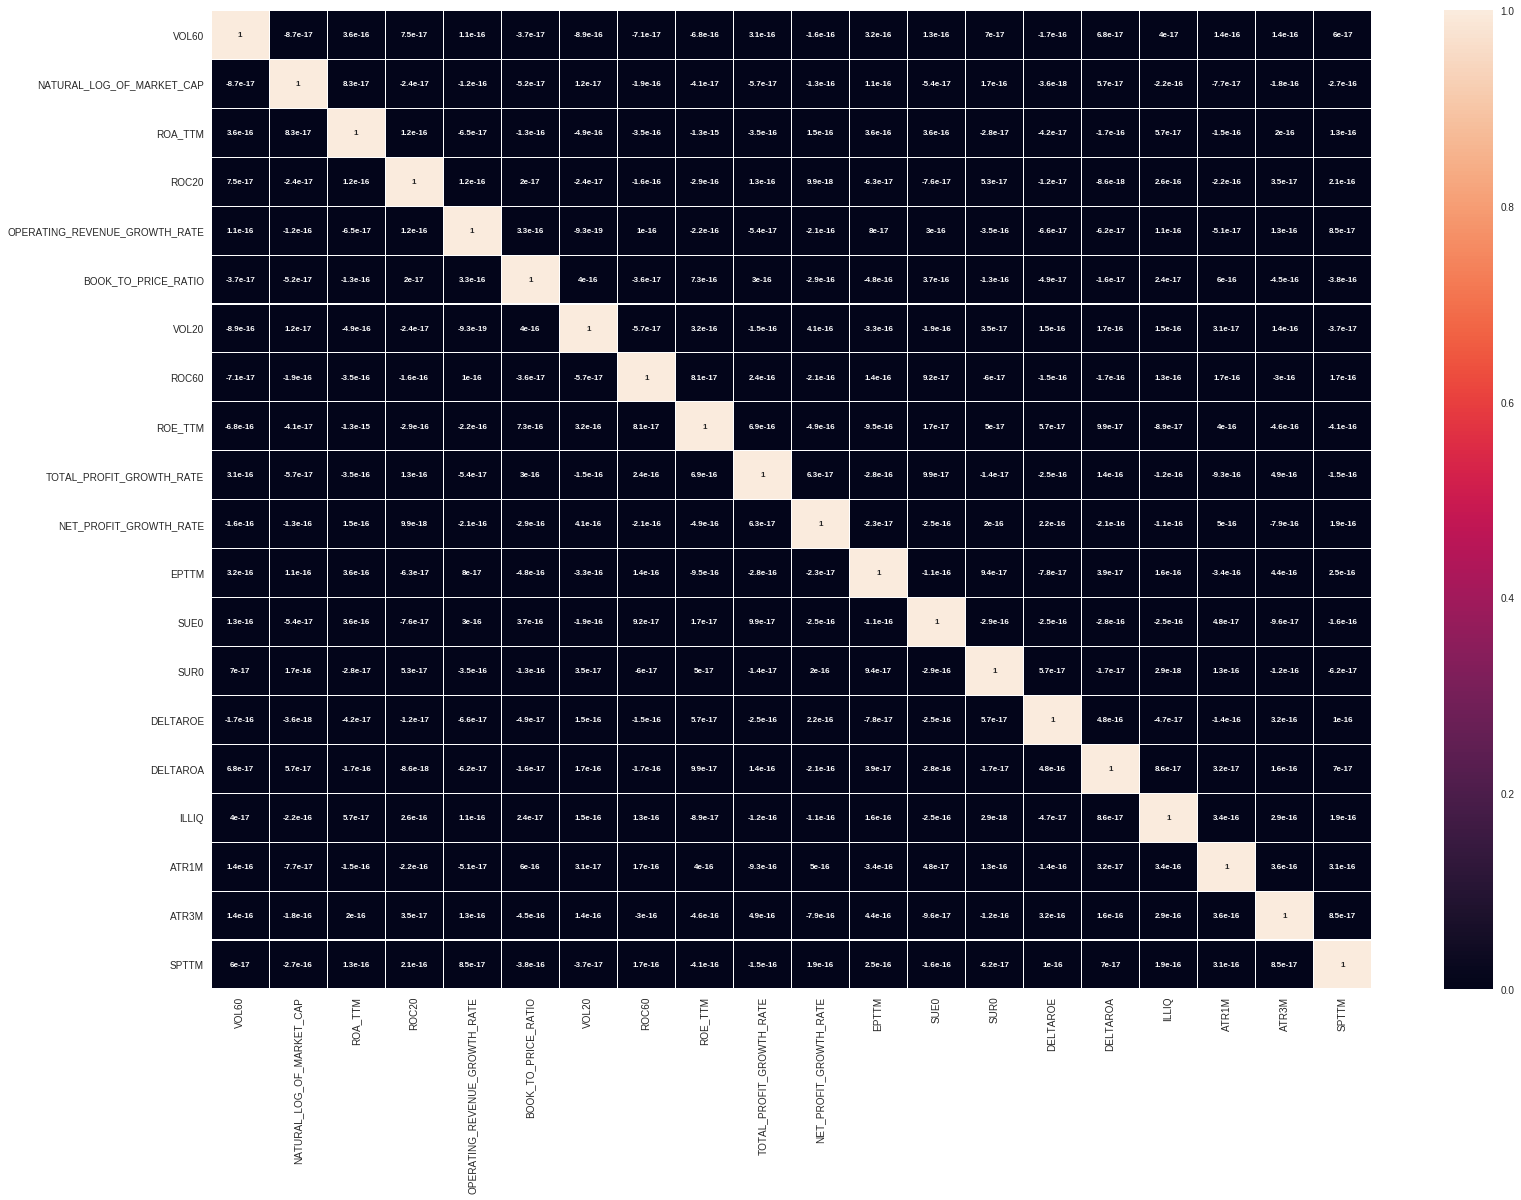

In [19]:
#绘制因子正交后的相关性热力图
fig=plt.figure(figsize=(26,18))
#计算对称正交之后的相关系数矩阵
relations= get_relations(factors5)  
sns.heatmap(relations,annot=True,linewidths=0.05,
            linecolor='white',annot_kws={'size':8,'weight':'bold'})

# 打分法计算预期收益
# 计算ICIR权重
在利用IR加权法计算权重时，各因子权重值为各因子在滚动时间内平均IR值在所有因子在滚动时间内平均IR值之和中的占比，因子在滚动时间内平均IR值越大，说明该因子在选股时作用越大，权重也越大，反之亦然。在利用IR计算权重时需注意的是：在滚动计算IC序列标准差时，起始日期得到的是缺失值，所以对于起始日期的IR值我们用该时点的IC值来代替， 得到的权重也为IC值计算的IC权重。

In [36]:
# 获取下期收益
def get_next_ret(data: pd.DataFrame, last_term_next_date: str) -> pd.Series:
    data = data.copy()
    
    securities = data.index.levels[1].tolist()
    period = [i.strftime('%Y-%m-%d') for i in data.index.levels[0]] 
    period.append(last_term_next_date)
    
    df = pd.concat([get_price(securities,end_date = i,count=1,fields='close',panel=False) for i in period])
    df = df.pivot(index = 'time',columns='code',values='close')
    
    ret = df.pct_change().shift(-1).iloc[:-1]
    ret_ser = ret.stack()
    return ret_ser

# 计算截面IC
def calc_rank_IC(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    factor_list = [i for i in data.columns.tolist() if i not in ['INDUSTRY_CODE','market_cap','NEXT_RET']]
    
    ic = data.groupby('date').apply(lambda x: [st.spearmanr(x[i],x['NEXT_RET'])[0] for i in factor_list])
    return pd.DataFrame(ic.tolist(),index = ic.index,columns = factor_list)

# 计算IR权重
def IR_weight(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    
    ic_df = calc_rank_IC(data)
    ic_mean = ic_df.rolling(window = 12).mean()
    ic_std = ic_df.rolling(window = 12).std()
    ir_df = ic_mean/ic_std
    ir_df.iloc[:11] = ic_df.iloc[:11]
    
    # Step 1: 负IR截断（研报：max(0, IR)）
    ir_positive = ir_df.clip(lower=0)

    # Step 2: 按行归一化（每行求和，每行相除）
    weights = ir_positive.div(ir_positive.sum(axis=1), axis=0)
    return weights

In [30]:
# 获取下期收益率
next_ret = get_next_ret(factors5,'2020-10-14')

factors5['NEXT_RET'] = next_ret

In [37]:
weights = IR_weight(factors5)
# 获取因子名称
factor_names = [name for name in factors5.columns if name not in [
    'INDUSTRY_CODE', 'market_cap', 'NEXT_RET']]

# 计算因子分数
factors5['SCORE'] = (factors5[factor_names].mul(weights)).sum(axis=1)
# 数据储存
factors5.to_csv('factors5.csv')

VOL60    ...        SCORE
date       code                     ...             
2010-01-29 000001.XSHE -0.075374    ...    -0.008505
           000002.XSHE  0.055259    ...    -0.010541
           000009.XSHE -0.040239    ...    -0.006536
           000012.XSHE  0.084249    ...    -0.014281
           000021.XSHE -0.037001    ...    -0.039512

[5 rows x 24 columns]

In [38]:
factors5.tail()

VOL60    ...        SCORE
date       code                     ...             
2020-09-30 603799.XSHG  0.107540    ...     0.001071
           603833.XSHG -0.000837    ...    -0.000782
           603899.XSHG  0.000837    ...     0.000782
           603986.XSHG -0.020526    ...     0.025352
           603993.XSHG -0.056191    ...     0.008298

[5 rows x 24 columns]

In [7]:
# 计算权重
def get_weights(symbol:str,start:str,end:str,method:str='cons')->pd.DataFrame:
    periods = getTradeDate(start,end,'ME')
    dic = {}
    
    if method == 'ind':
        for i in periods:
            weight = get_index_weights(symbol,i)
            weight['ind'] = IndustryMktcap(weight.index.tolist(),i).iloc[:,0]
            dic[i] = weight.groupby('ind')['weight'].sum()/100
        weight_df = pd.concat(dic,names = ['date','industry']).reset_index()
        weight_df['date']= pd.to_datetime(weight_df['date'])
        return weight_df.set_index(['date','industry'])
    
    elif method == 'cons':
        df = pd.concat(get_index_weights(symbol,i) for i in periods)
        df.drop(columns = 'display_name',inplace = True)
        df.index.name = 'code'
        df = df.reset_index()
        df = df.set_index(['date','code'])
        df['weight'] = df['weight'] / 100
        return df

# 分组方法    
def get_group(ser:pd.Series,N:int=3,ascend:bool=True)->pd.Series:    
    ser = ser.rank(ascending = ascend)
    label = [f'G{i}' for i in range(1,N+1)]
    return  pd.cut(ser,bins=N,labels = label)



# 分层抽样
def stratified_sampling(symbol: str, START_DATE: str, END_DATE: str, factors: pd.DataFrame) -> pd.DataFrame:
    factors = factors.copy()
    weight_df = get_weights(symbol,START_DATE,END_DATE)
    
    g1 = [pd.Grouper(level = 'date'),pd.Grouper(key = 'INDUSTRY_CODE')]
    factors['GROUP'] = factors.groupby(g1)['market_cap'].apply(get_group)
    
    factors['weight'] = weight_df['weight']
    g2 = [pd.Grouper(level = 'date'),pd.Grouper(key = 'INDUSTRY_CODE'),pd.Grouper(key='GROUP')]
    factors['group_weight'] = factors.groupby(g2)['weight'].transform('sum')
    
    tmp = factors.groupby(g2)['SCORE'].apply(lambda x : x.idxmax()[1]).rename('code')
    tmp = tmp.reset_index()
    tmp = tmp.set_index(['date','code'])
    
    
    tmp['group_weight'] = factors['group_weight']
    tmp['w'] = tmp.groupby(level = 'date')['group_weight'].transform(lambda x: x/x.sum())
    
    tmp['NEXT_RET'] = factors['NEXT_RET']
    return tmp

    
    

In [9]:
factors5 = pd.read_csv('factors5.csv',index_col=[0,1],parse_dates=[0],dtype={'INDUSTRY_CODE':str})

# 获取分层数据
result_df1 = stratified_sampling('000300.XSHG', START_DATE, END_DATE, factors5[[
                                'INDUSTRY_CODE', 'market_cap', 'SCORE', 'NEXT_RET']])

result_df1.to_csv('result_df1.csv')
result_df1.head()

INDUSTRY_CODE GROUP    ...            w  NEXT_RET
date       code                               ...                       
2010-01-29 600816.XSHG        801190    G1    ...     0.018794  0.053279
           600837.XSHG        801190    G2    ...     0.157918  0.004680
           601998.XSHG        801190    G3    ...     0.158098  0.002976
           600638.XSHG        801180    G1    ...     0.012301  0.034549
           601588.XSHG        801180    G2    ...     0.011434  0.037129

[5 rows x 5 columns]

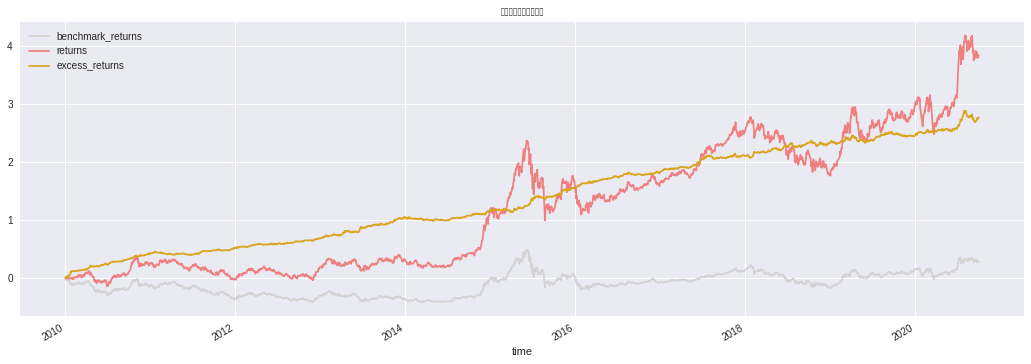

In [10]:
# 根据result_df文件中生成的权重及股票名单进行回测
# 获取回测结果
gt = get_backtest('c3d41a5c2b57553800f50740388d0817')

algorithm = pd.DataFrame(gt.get_results()).set_index('time')
algorithm['excess_returns'] = (
    algorithm['returns'] + 1) / (algorithm['benchmark_returns'] + 1) - 1

algorithm.index = pd.to_datetime(algorithm.index)
algorithm.plot.line(figsize=(18, 6), title='分层抽样指数增强策略', color=[
                    'LightGrey', 'LightCoral', 'GoldenRod'])

In [11]:
# 风险指标如下
pd.Series(gt.get_risk()).iloc[1:]

algorithm_return                                       3.8399
algorithm_volatility                                 0.237713
alpha                                                0.138704
annual_algo_return                                   0.162778
annual_bm_return                                    0.0241154
avg_excess_return                                 0.000513459
avg_position_days                                     304.362
avg_trade_return                                    0.0442439
benchmark_return                                     0.282945
benchmark_volatility                                 0.231394
beta                                                   1.0026
day_win_ratio                                        0.557383
excess_return                                         2.77249
excess_return_max_drawdown                          0.0491855
excess_return_max_drawdown_period    [2020-07-30, 2020-09-14]
excess_return_sharpe                                  1.83302
informat

#  采用华泰研报的线性规划模型优化权重：
#（不考虑个股和因子的协方差矩阵，只通过线性规划来完成组合构建。）
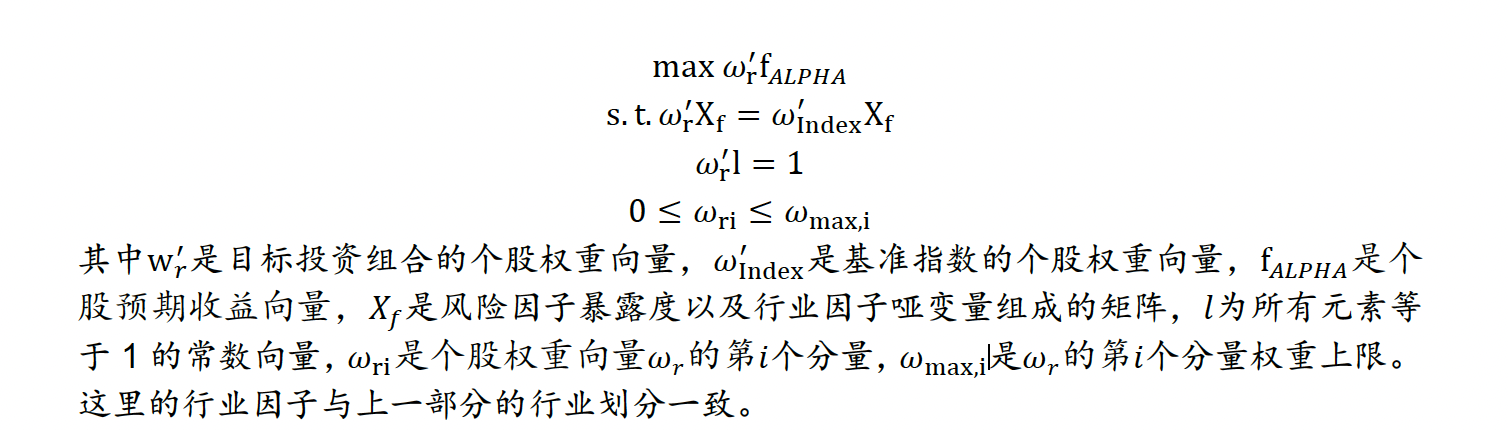

In [15]:
from scipy.optimize import linprog


def get_optimization_weight(df: pd.DataFrame):

    df_ = df.copy()
    index_weight = df_['weight'].values
    score = df_['SCORE'].values

    X = df_.drop(columns=['SCORE', 'weight']).T.values
    n = len(df_)
    c = -score


    A_eq = np.vstack([X,np.ones(n)])

    b_eq = np.concatenate([X @ index_weight,[1.0]])

    upper_bound = 2 * index_weight

    bounds = [(0, upper_bound[i]) for i in range(n)]

    res = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
    )

    if not res.success:
        print(df.name)
        print(res.message)

    return pd.Series(
        res.x,
        index=df_.index.get_level_values(1)
    )


In [11]:
def optimization_result(symbol:str,start:str,end:str,factors:pd.DataFrame)->pd.DataFrame:
    '''
    获取优化权重后的结果
    '''
    factors = factors.copy()
    ind_weight = get_weights(symbol, start, end)
    factors['weight'] = ind_weight['weight']
    factors['weight'] = factors.groupby(level='date')['weight'].transform(lambda x: x/x.sum())


    select_col = [col for col in factors.columns if col not in ['market_cap','NEXT_RET']]

    df = pd.get_dummies(factors[select_col],columns=['INDUSTRY_CODE'])
    
    result_df = df.groupby(level='date').apply(get_optimization_weight)
    
    return result_df.to_frame('w')

In [16]:
factors5 = pd.read_csv('factors5.csv',index_col=[0,1],parse_dates=[0],dtype={'INDUSTRY_CODE':str})
result_df2 = optimization_result('000300.XSHG',START_DATE,END_DATE,factors5)

2010-01-29 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 3.4e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 3.4e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2010-02-26 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 2.5e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 2.5e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2010-03-31 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 2.6e-01 which exceeds the required tolerance of 1e-12 for a solution to be cons

2012-03-30 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 2.6e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 2.6e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2012-04-27 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 1.4e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 1.4e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2012-06-29 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 6.7e-02 which exceeds the required tolerance of 1e-12 for a solution to be cons

2014-01-30 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 2.9e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 2.9e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2014-02-28 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 3.5e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 3.5e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2014-03-31 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 4.8e-01 which exceeds the required tolerance of 1e-12 for a solution to be cons

2015-10-30 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 3.3e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 3.3e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2015-11-30 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 4.2e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 4.2e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2015-12-31 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 3.2e-01 which exceeds the required tolerance of 1e-12 for a solution to be cons

2017-07-31 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 3.6e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 3.6e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2017-08-31 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 3.0e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 3.0e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2017-09-29 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 4.3e-01 which exceeds the required tolerance of 1e-12 for a solution to be cons

2019-04-30 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 4.4e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 4.4e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2019-05-31 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 5.9e-01 which exceeds the required tolerance of 1e-12 for a solution to be considered 'close enough' to zero to be a basic solution. Consider increasing the tolerance to be greater than 5.9e-01. If this tolerance is unacceptably  large the problem may be infeasible.
2019-06-28 00:00:00
Phase 1 of the simplex method failed to find a feasible solution. The pseudo-objective function evaluates to 5.5e-01 which exceeds the required tolerance of 1e-12 for a solution to be cons

In [18]:
result_df2.to_csv('result_df2.csv')
result_df2.head()

w
date       code                 
2010-01-29 000001.XSHE  0.029508
           000002.XSHE  0.004558
           000009.XSHE  0.004974
           000012.XSHE  0.000000
           000021.XSHE  0.002098

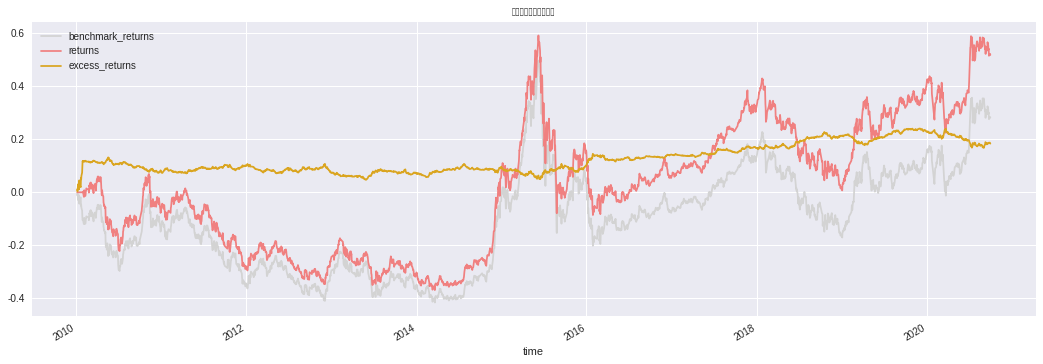

In [19]:
# 获取回测结果
gt = get_backtest('fe389884da889a774455f0e617941f10')

algorithm = pd.DataFrame(gt.get_results()).set_index('time')
algorithm['excess_returns'] = (
    algorithm['returns'] + 1) / (algorithm['benchmark_returns'] + 1) - 1

algorithm.index = pd.to_datetime(algorithm.index)
algorithm.plot.line(figsize=(18, 6), title='分层抽样指数增强策略', color=[
                    'LightGrey', 'LightCoral', 'GoldenRod'])